# 네일 이커머스 사전 전처리

원본 REES46 월별 CSV → 네일 시장 분석용 데이터셋 구성 근거

- 원본 5개월 CSV 명시 로드
- `category_code` 기준 제외 사유 확인
- GPT 기반 브랜드 카테고리 분류 후 네일 중심 브랜드 중심 분석
- 불필요 컬럼 및 가격 이상치 제거
- `event_time` UTC+3 표준화


## 1. 환경 설정

기본 라이브러리 및 시간대 기준


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LOCAL_TIMEZONE = 'Etc/GMT-3'  # UTC+3


C:\Users\ckcma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. 원본 월별 CSV 로드

일반적인 `pd.read_csv()` 형태로 파일명 명시

사용 파일
- `2019-Oct.csv`
- `2019-Nov.csv`
- `2019-Dec.csv`
- `2020-Jan.csv`
- `2020-Feb.csv`


In [2]:
oct_2019 = pd.read_csv('2019-Oct.csv')
nov_2019 = pd.read_csv('2019-Nov.csv')
dec_2019 = pd.read_csv('2019-Dec.csv')
jan_2020 = pd.read_csv('2020-Jan.csv')
feb_2020 = pd.read_csv('2020-Feb.csv')

file_check = pd.DataFrame({
    'file_name': ['2019-Oct.csv', '2019-Nov.csv', '2019-Dec.csv', '2020-Jan.csv', '2020-Feb.csv'],
    'rows': [len(oct_2019), len(nov_2019), len(dec_2019), len(jan_2020), len(feb_2020)],
    'columns': [oct_2019.shape[1], nov_2019.shape[1], dec_2019.shape[1], jan_2020.shape[1], feb_2020.shape[1]],
})

display(file_check)


,file_name,rows,columns
0,2019-Oct.csv,4102283,9
1,2019-Nov.csv,4635837,9
2,2019-Dec.csv,3533286,9
3,2020-Jan.csv,4264752,9
4,2020-Feb.csv,4156682,9


## 3. 컬럼 구조 확인

월별 파일 컬럼 일치 여부 확인


In [3]:
print(oct_2019.columns.tolist())
print(nov_2019.columns.tolist())
print(dec_2019.columns.tolist())
print(jan_2020.columns.tolist())
print(feb_2020.columns.tolist())

print(oct_2019.columns.equals(nov_2019.columns))
print(oct_2019.columns.equals(dec_2019.columns))
print(oct_2019.columns.equals(jan_2020.columns))
print(oct_2019.columns.equals(feb_2020.columns))


['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
True
True
True
True


## 4. 월별 데이터 통합

5개월 원본 데이터 단일 데이터프레임 구성


In [4]:
df = pd.concat([oct_2019, nov_2019, dec_2019, jan_2020, feb_2020], axis=0, ignore_index=True)

print(df.shape)
display(df.head())


(20692840, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
2,2019-10-01 00:00:07 UTC,cart,5881589,2151191071051219817,NaN,lovely,13.48,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,NaN,runail,2.62,463240011,26dd6e6e-4dac-4778-8d2c-92e149dab885
4,2019-10-01 00:00:15 UTC,cart,5881449,1487580013522845895,NaN,lovely,0.56,429681830,49e8d843-adf3-428b-a2c3-fe8bc6a307c9


## 5. 전체 시장 품질 점검

기존 EDA 핵심 확인값
- `category_code`: 고결측, 네일 분류 대표성 낮음
- `brand`: 결측 존재, 브랜드 기준 필터링 전 규모 확인 필요
- `user_session`: 일부 결측, 메인 분석 직접 사용 없음
- `price <= 0`: 데이터 오류 판단, 제거 대상


In [5]:
display(df.info())
display(df.isna().sum())
display(df['price'].describe())
display(df['event_type'].value_counts(normalize=True))

print(df['brand'].nunique())
print(df['product_id'].nunique())
print(df['user_id'].nunique())


<class 'pandas.DataFrame'>
RangeIndex: 20692840 entries, 0 to 20692839
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 2.7 GB


None

event_time              0
event_type              0
product_id              0
category_id             0
category_code    20339246
brand             8757117
price                   0
user_id                 0
user_session         4598
dtype: int64

count    2.069284e+07
mean     8.534735e+00
std      1.938142e+01
min     -7.937000e+01
25%      2.060000e+00
50%      4.050000e+00
75%      7.060000e+00
max      3.277800e+02
Name: price, dtype: float64

event_type
view                0.466723
cart                0.278760
remove_from_cart    0.192322
purchase            0.062196
Name: proportion, dtype: float64

273


54571


1639358


## 6. category_code 기준 제외 근거

- category_code 결측 비중 높음
- 네일 관련 상품도 가전/가구/액세서리 등으로 분산
- accessories.cosmetic_bag 외 화장품/네일 직접 분류 부족
- 최종 필터 기준: category_code가 아닌 브랜드 리스트로 카테고리 재분류 필요


In [6]:
display(df['category_code'].value_counts(dropna=False).head(30))

runail_category = df[(df['brand'] == 'runail') & (df['category_code'].notna())]
irisk_category = df[(df['brand'] == 'irisk') & (df['category_code'].notna())]
grattol_category = df[(df['brand'] == 'grattol') & (df['category_code'].notna())]

display(runail_category[['brand', 'category_code']].value_counts())
display(irisk_category[['brand', 'category_code']].value_counts())
display(grattol_category[['brand', 'category_code']].value_counts())


category_code
NaN                                       20339246
appliances.environment.vacuum               149168
stationery.cartrige                          59728
apparel.glove                                52575
furniture.living_room.cabinet                30560
accessories.bag                              24253
furniture.bathroom.bath                      23931
appliances.personal.hair_cutter               5384
accessories.cosmetic_bag                      3644
appliances.personal.massager                  3296
appliances.environment.air_conditioner         708
furniture.living_room.chair                    343
sport.diving                                     4
Name: count, dtype: int64

brand   category_code                
runail  appliances.environment.vacuum    16400
        furniture.living_room.cabinet     5754
        furniture.bathroom.bath           1735
        stationery.cartrige               1445
Name: count, dtype: int64

brand  category_code                
irisk  appliances.environment.vacuum    10684
       furniture.bathroom.bath           7733
       furniture.living_room.cabinet     2196
       accessories.cosmetic_bag            32
       apparel.glove                       18
       accessories.bag                     10
Name: count, dtype: int64

Series([], Name: count, dtype: int64)

## 7. 브랜드 카테고리 점유율

brand 결측 약 875만 행, category_code 네일 판별 한계 확인

수기 브랜드 맵 기준 Nail 766만 건, 단일 카테고리 1위


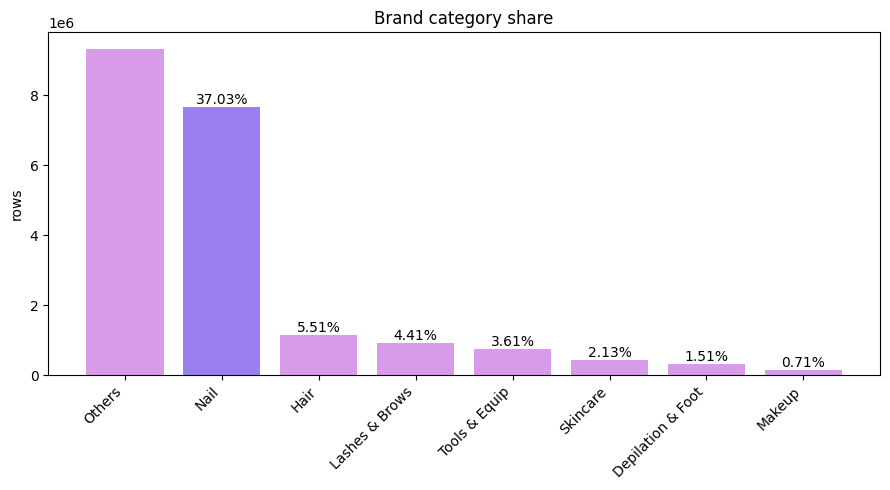

,category,count,ratio(%)
0,Others,9331671,45.10
1,Nail,7661606,37.03
2,Hair,1139607,5.51
3,Lashes & Brows,913359,4.41
4,Tools & Equip,746415,3.61
5,Skincare,441018,2.13
6,Depilation & Foot,312704,1.51
7,Makeup,146460,0.71


brand_missing_rows       8757117.00
brand_missing_rate(%)         42.32
nail_rows                7661606.00
nail_rate(%)                  37.03
dtype: float64

In [ ]:
# 브랜드 사전 기반 카테고리 매핑
# GPT·외부 검색 보조로 브랜드 후보 검증
brand_cat_map = {
    'Nail': [
        'runail', 'lianail', 'irisk', 'masura', 'ingarden', 'de.lux', 'milv',
        'f.o.x', 'cnd', 'grattol', 'bluesky', 'pole', 'jessnail', 'haruyama',
        'rosi', 'airnails', 'beautix', 'uno', 'entity', 'beauty-free',
        'kinetics', 'cosmoprofi', 'pnb', 'domix', 'enas', 'oniq', 'sophin',
        'uskusi', 'solomeya', 'artex', 'orly', 'tertio', 'inm', 'candy',
        'i-laq', 'blixz', 'lamixx', 'opi', 'enigma', 'rocknailstar',
        'vl-gel', 'pueen', 'naomi', 'ibd', 'dartnails', 'yllozure',
        'strong', 'essie', 'tosowoong'
    ],
    'Hair': [
        'kapous', 'estel', 'keen', 'concept', 'cutrin', 'matrix', 'kaypro',
        'kaaral', 'lador', 'chi', 'insight', 'osmo', 'keune', 'lakme',
        'joico', 'farmavita', 'kerasys', 'coocla', 'nirvel', 'biofollica',
        'ellips', 'protokeratin', 'mielle', 'koreatida', 'grace', 'latinoil',
        'foamie', 'tazol', 'bosnic', 'zab', 'macadamia', 'laiseven',
        'esquire', 'dessata', 'greymy', 'ecolab', 'kezy', 'barex', 'kondor',
        'dancoly', 'frozen', 'ikoo'
    ],
    'Lashes & Brows': [
        'lovely', 'nagaraku', 'bpw.style', 'thuya', 'shik', 'browxenna',
        'profhenna', 'ardell', 'bespecial', 'levissime', 'refectocil',
        'provoc', 'godefroy', 'inoface', 'andrea', 'binacil', 'fly',
        'weaver', 'matreshka', 'mayamy'
    ],
    'Tools & Equip': [
        'yoko', 'roubloff', 'strong', 'staleks', 'metzger', 'emil', 'sun', 'sunuv',
        'nitrile', 'nitrimax', 'zinger', 'jaguar', 'coifin', 'marutaka-foot',
        'sanoto', 'philips', 'mane', 'benovy', 'dewal', 'babyliss',
        'termix', 'gezatone', 'marathon', 'juno'
    ],
    'Skincare': [
        'bioaqua', 'dizao', 'levrana', 'farmstay', 'skinlite', 'shary',
        'markell', 'likato', 'treaclemoon', 'freshbubble', 'consly',
        'dermal', 'vilenta', 'missha', 'bodyton', 'elskin', 'kares',
        'koelf', 'deoproce', 'bergamo', 'litaline', 'tosowoong', 'miskin',
        'beauugreen', 'lebelage', 'lsanic', 'kamill', 'farmona', 'fancy',
        'riche', 'estelare', 'ypsed', 'laboratorium', 'nefertiti', 'zeitun',
        'kims', 'coxir', 'ladykin', 's.care', 'labay', 'yu-r', 'kocostar',
        'eunyul', 'helloganic', 'dr.gloderm', 'naturmed', 'skipofit',
        'eos', 'veraclara', 'glysolid', 'ovale', 'cruset', 'supertan',
        'elizavecca', 'neoleor', 'biore', 'koelcia', 'embryolisse',
        'voesh', 'bodipure', 'skinity', 'cosima', 'lunaris', 'shifei',
        'aura', 'ecocraft', 'biorepair', 'beautific', 'herbolive',
        'arganoil', 'bielenda', 'vichy', 'bioderma', 'everyang', 'rorec',
        'pilaten', 'dobrovit', 'cettua', 'plazan'
    ],
    'Depilation & Foot': [
        'italwax', 'depilflax', 'gehwol', 'soleo', 'polarus', 'finish',
        'dorena', 'cuccio', 'profepil', 'footlogix'
    ],
    'Makeup': [
        'art-visage', 'limoni', 'kosmekka', 'dermacol', 'beautyblender',
        'estrade', 'relouis', 'note', 'luxvisage', 'avene', 'blise'
    ],
}

# 브랜드 기준 카테고리 규모 산출
# category_code 결측·오분류 보완 목적
cat_counts = {
    cat: int(df['brand'].isin(brands).sum())
    for cat, brands in brand_cat_map.items()
}

# 미분류 브랜드 Others 처리
cat_counts['Others'] = int(len(df) - sum(cat_counts.values()))

# 카테고리별 행 수·비율 테이블
cat_order = ['Others', 'Nail', 'Hair', 'Lashes & Brows', 'Tools & Equip', 'Skincare', 'Depilation & Foot', 'Makeup']
brand_cat_sum = pd.DataFrame({
    'category': cat_order,
    'count': [cat_counts[x] for x in cat_order],
})
brand_cat_sum['ratio(%)'] = (brand_cat_sum['count'] / len(df) * 100).round(2)

# 브랜드 결측치 확인
brand_missing = df['brand'].isna().sum()


# 브랜드 카테고리 비중 시각화
plt.figure(figsize=(9, 5))
colors = ['#d89be9' if x != 'Nail' else '#9a7ff0' for x in brand_cat_sum['category']]
bars = plt.bar(brand_cat_sum['category'], brand_cat_sum['count'], color=colors)

plt.xticks(rotation=45, ha='right')
plt.ylabel('rows')
plt.title('Brand category share')

# 비율 라벨 표시
for bar, pct in zip(bars, brand_cat_sum['ratio(%)']):
    if bar.get_x() + bar.get_width() / 2 == 0:
        continue
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{pct:.2f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

display(brand_cat_sum)

# 네일 브랜드 필터링 기준 요약
pd.Series({
    'brand_missing_rows': brand_missing,
    'brand_missing_rate(%)': round(brand_missing / len(df) * 100, 2),
    'nail_rows': int(brand_cat_sum.loc[brand_cat_sum['category'] == 'Nail', 'count'].iloc[0]),
    'nail_rate(%)': float(brand_cat_sum.loc[brand_cat_sum['category'] == 'Nail', 'ratio(%)'].iloc[0]),
})


## 8. 브랜드 기준 네일 시장 후보 선정

선정 근거
- 원본 시장: 복수 뷰티/생활 카테고리 혼재
- 브랜드별 거래량, 매출, 평균가, 상품 수, 유저 수 확인
- GPT/외부 검색 보조: 브랜드별 중심 카테고리 검토
- 네일 아트 제품 중심 브랜드 유지
- 네일 머신/종합 잡화 성격 강한 브랜드 제외

예시 판단
- `runail`, `irisk`, `grattol`: 네일 아트 제품 중심
- `strong`: 거래액 크지만 네일 머신 중심, 고가 객단가 성격
- `jessnail`: 저가/다품종 성격이나 네일 관련 거래 비중 고려

원본 GPT 분류표 부재. 재현 가능한 브랜드 프로파일 및 최종 리스트 보존


In [8]:
brand_count = df['brand'].value_counts()
brand_sales = df.groupby('brand')['price'].sum().sort_values(ascending=False)
brand_price_mean = df.groupby('brand')['price'].mean().sort_values(ascending=False)

display(brand_count.head(30))
display(brand_sales.head(30))
display(brand_price_mean.head(30))


brand
runail        1528908
irisk         1033852
masura         861763
grattol        852591
bpw.style      434813
ingarden       430958
estel          360912
kapous         324394
jessnail       252996
uno            250377
freedecor      237023
italwax        225667
concept        201312
bluesky        201175
pole           199154
haruyama       192224
cnd            177662
milv           166970
domix          158344
lianail        133388
cosmoprofi     126462
zinger         124598
oniq           116305
staleks        112076
f.o.x          111657
nagaraku       108617
lovely         107856
uskusi         100778
beautix         99456
yoko            99291
Name: count, dtype: int64

brand
strong        11982117.62
jessnail      10187422.07
runail         9372816.70
irisk          6730044.50
grattol        4666589.40
marathon       4467685.53
cnd            3048604.43
masura         2922473.29
uno            2547172.84
estel          2533038.87
max            2369198.16
ingarden       2175982.49
polarus        2105754.28
kosmekka       1976036.85
italwax        1932969.26
browxenna      1522823.74
sunuv          1343352.51
shik           1307471.77
emil           1289492.23
jas            1281168.38
kapous         1262898.28
beautix        1223797.25
concept        1221619.51
staleks        1150676.88
oniq           1134995.49
bluesky        1037102.78
cosmoprofi     1018169.00
domix           959361.28
lovely          942207.38
airnails        934426.31
Name: price, dtype: float64

brand
strong         197.356705
sanoto         135.859385
marathon       132.434727
dorena         113.721021
s.care         101.073185
kosmekka        83.033736
sun             77.577042
babyliss        72.973969
max             69.208020
kondor          61.218268
polarus         60.181603
blise           59.340678
vosev           57.928470
coifin          57.781901
neoleor         56.766214
emil            52.737812
gezatone        51.186540
sunuv           49.595825
jas             47.406786
jaguar          47.271485
mane            45.962833
thuya           44.541480
embryolisse     44.256852
jessnail        40.267127
joico           38.025704
kims            33.928306
yu-r            33.833186
greymy          31.136390
latinoil        30.055209
esquire         29.017473
Name: price, dtype: float64

## 9. 네일 브랜드 리스트 확정

기존 전처리 노트북의 최종 네일 브랜드 리스트 보존


In [9]:
NAIL_BRANDS = [
    'runail', 'lianail', 'irisk', 'masura', 'ingarden', 'de.lux', 'milv',
    'f.o.x', 'cnd', 'grattol', 'bluesky', 'pole', 'jessnail', 'haruyama',
    'rosi', 'airnails', 'beautix', 'uno', 'entity', 'beauty-free',
    'kinetics', 'cosmoprofi', 'pnb', 'domix', 'enas', 'oniq', 'sophin',
    'uskusi', 'solomeya', 'artex', 'orly', 'tertio', 'inm', 'candy',
    'i-laq', 'blixz', 'lamixx', 'opi', 'enigma', 'rocknailstar',
    'vl-gel', 'pueen', 'naomi', 'ibd', 'dartnails', 'yllozure'
]

nail_brand_count = df[df['brand'].isin(NAIL_BRANDS)]['brand'].value_counts()

print(len(NAIL_BRANDS))
print(nail_brand_count.shape[0])
display(nail_brand_count)


46
46


brand
runail          1528908
irisk           1033852
masura           861763
grattol          852591
ingarden         430958
jessnail         252996
uno              250377
bluesky          201175
pole             199154
haruyama         192224
cnd              177662
milv             166970
domix            158344
lianail          133388
cosmoprofi       126462
oniq             116305
f.o.x            111657
uskusi           100778
beautix           99456
pnb               92803
airnails          82224
de.lux            80560
kinetics          57334
solomeya          50733
rosi              44418
beauty-free       31249
artex             26015
sophin            24022
entity            19964
dartnails         15158
opi               13519
orly              12364
i-laq             10183
tertio             7807
lamixx             7076
naomi              5726
enigma             5579
candy              4449
yllozure           4090
inm                3498
enas               3377
blixz     

## 10. 네일 브랜드 필터링 및 컬럼 정리

처리 요약
- 네일 브랜드 행동 로그만 유지
- category_code: 고결측/오분류, 최종 필터 기준 제외
- user_session : 결측 존재, 메인 분석 직접 사용 없음


In [10]:
nail = df[df['brand'].isin(NAIL_BRANDS)].copy()
nail = nail.drop(columns=['category_code', 'user_session'])

print(nail.shape)
display(nail.head())
display(nail.isna().sum())


(7600556, 7)


,event_time,event_type,product_id,category_id,brand,price,user_id
0,2019-10-01 00:00:00 UTC,cart,5773203,1487580005134238553,runail,2.62,463240011
1,2019-10-01 00:00:03 UTC,cart,5773353,1487580005134238553,runail,2.62,463240011
3,2019-10-01 00:00:07 UTC,cart,5723490,1487580005134238553,runail,2.62,463240011
5,2019-10-01 00:00:16 UTC,cart,5857269,1487580005134238553,runail,2.62,430174032
10,2019-10-01 00:00:28 UTC,view,5692917,1487580004857414477,lianail,5.54,555446068


event_time     0
event_type     0
product_id     0
category_id    0
brand          0
price          0
user_id        0
dtype: int64

## 11. 가격 이상치 제거

price <= 0 행 제거


In [11]:
minus_price = nail[nail['price'] <= 0]

display(minus_price.head())
display(minus_price['event_type'].value_counts())

nail_v2 = nail[nail['price'] > 0].copy()
print(nail_v2.shape)


,event_time,event_type,product_id,category_id,brand,price,user_id
1362378,2019-10-10 06:12:28 UTC,view,5837453,1487580007432717250,ingarden,0.0,542521900
5346010,2019-11-09 19:34:47 UTC,view,5611152,1487580005671109489,masura,0.0,569463096
5919692,2019-11-14 07:32:45 UTC,view,5837548,1487580006551913373,bluesky,0.0,571339840
8449523,2019-11-29 11:23:46 UTC,view,5837557,1487580005134238553,runail,0.0,472930284
8795938,2019-12-01 13:34:44 UTC,view,5837552,1487580008984608779,runail,0.0,401791394


event_type
view    14
Name: count, dtype: int64

(7600542, 7)


## 12. 이벤트 시간 표준화

원본 event_time: UTC 문자열

처리 방식
- 문자열 끝 UTC 제거
- UTC 기준 datetime 파싱
- 러시아 UTC+3 기준 변환


In [12]:
s = nail_v2['event_time'].astype(str).str.replace(r'\s*UTC$', '', regex=True)

nail_v2['event_time'] = pd.to_datetime(
    s,
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce',
    utc=True
).dt.tz_convert(LOCAL_TIMEZONE)

print(nail_v2['event_time'].isna().sum())
print(nail_v2['event_time'].min())
print(nail_v2['event_time'].max())


0
2019-10-01 03:00:00+03:00
2020-03-01 02:59:59+03:00


## 13. 최종 검증

GitHub 기록용 출력
- 최종 행/열
- 브랜드/상품/유저 수
- 이벤트 타입 분포
- 상위 브랜드 거래 규모
- CSV 저장 생략


In [13]:
print(nail_v2.shape)
print(nail_v2['brand'].nunique())
print(nail_v2['product_id'].nunique())
print(nail_v2['user_id'].nunique())

display(nail_v2['event_type'].value_counts())
display(nail_v2.groupby('brand')['price'].sum().sort_values(ascending=False).head(20))
display(nail_v2.head())

print('skip save')


(7600542, 7)


46
18077


657030


event_type
view                3354923
cart                2175819
remove_from_cart    1590875
purchase             478925
Name: count, dtype: int64

brand
jessnail      10187422.07
runail         9372816.70
irisk          6730044.50
grattol        4666589.40
cnd            3048604.43
masura         2922473.29
uno            2547172.84
ingarden       2175982.49
beautix        1223797.25
oniq           1134995.49
bluesky        1037102.78
cosmoprofi     1018169.00
domix           959361.28
airnails        934426.31
lianail         809139.71
pole            772574.41
haruyama        749534.52
f.o.x           729745.44
pnb             622411.89
kinetics        570141.29
Name: price, dtype: float64

,event_time,event_type,product_id,category_id,brand,price,user_id
0,2019-10-01 03:00:00+03:00,cart,5773203,1487580005134238553,runail,2.62,463240011
1,2019-10-01 03:00:03+03:00,cart,5773353,1487580005134238553,runail,2.62,463240011
3,2019-10-01 03:00:07+03:00,cart,5723490,1487580005134238553,runail,2.62,463240011
5,2019-10-01 03:00:16+03:00,cart,5857269,1487580005134238553,runail,2.62,430174032
10,2019-10-01 03:00:28+03:00,view,5692917,1487580004857414477,lianail,5.54,555446068


skip save
